In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import scipy.io as sio

In [5]:
cov1 = np.array(
    [
        [1/2**2, 0.05],
        [0.05, 1/3**2],
    ]
)
cov2 = np.array(
    [
        [1/4**2, -0.05],
        [-0.05, 1/2**2],
    ]
)
T = 1
eps = 0.5
mu1 = np.array([0.5, 0.5]).reshape([1, -1])
mu2 = np.array([-0.5, -0.5]).reshape([1, -1])

In [6]:
y01 = np.random.multivariate_normal(mean=mu1.flatten(), cov=cov1, size=500000)
y02 = np.random.multivariate_normal(mean=mu2.flatten(), cov=cov2, size=500000)
y0 = np.concatenate([y01, y02], axis=0)

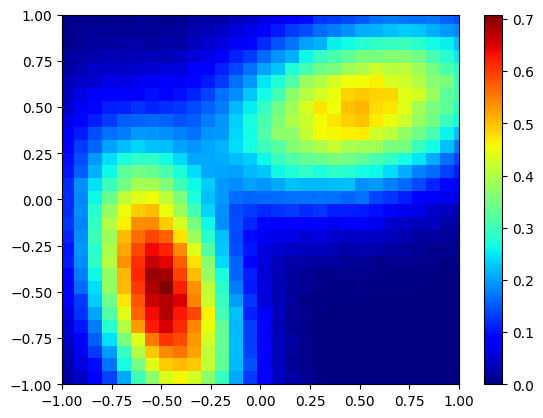

In [7]:
plt.hist2d(y0[:, 0], y0[:, 1], bins=(70, 70), density=True, cmap=colormaps["jet"])
plt.xlim([-1., 1.])
plt.ylim([-1., 1.])
plt.colorbar()
plt.show()

In [8]:
Nt = 101
t = np.linspace(0, T, Nt)
ys = [y0]
dt = t[1] - t[0]
for i in range(int(T/dt)):
    ys += [ys[-1] + np.sqrt(dt * eps) * np.random.normal(size=y0.shape)]
ys = np.stack(ys)
ys = np.transpose(ys, [1, 0, 2])

In [6]:
sio.savemat(
    "./train.mat",
    {
        "t": t,
        "ys": ys,
        "eps": eps,
    }
)